In [1]:
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import dataset (Amazon Reviews)

In [2]:
reviews = pd.read_csv("../datasets/Reviews.csv")
reviews.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

### Data preprocessing

In [3]:
reviews = reviews[["Text", "Score"]]

In [4]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Text    568454 non-null  object
 1   Score   568454 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 8.7+ MB


In [5]:
reviews.head()

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


In [6]:
scores = list(np.unique(reviews.Score.values))
scores_counts = reviews.Score.value_counts().sort_index()

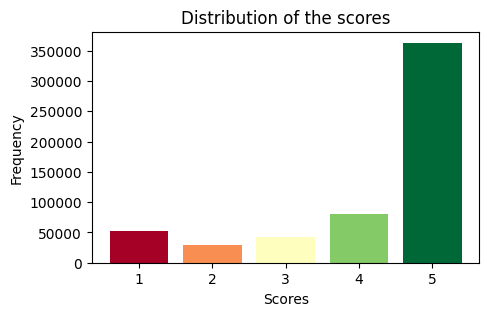

In [7]:
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(scores)))

plt.figure(figsize=(5,3))
plt.bar(scores, scores_counts, color = colors)
plt.title('Distribution of the scores')
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.show()

In [8]:
sentiments = {
    1:'negative',
    2:'negative',
    3:'neutral',
    4:'positive',
    5:'positive'
}

sentiments

{1: 'negative', 2: 'negative', 3: 'neutral', 4: 'positive', 5: 'positive'}

In [9]:
reviews['Sentiment'] = reviews['Score'].map(sentiments)

In [10]:
reviews.head()

,Text,Score,Sentiment
0,I have bought several of the Vitality canned d...,5,positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,negative
2,This is a confection that has been around a fe...,4,positive
3,If you are looking for the secret ingredient i...,2,negative
4,Great taffy at a great price. There was a wid...,5,positive


In [11]:
senti= list(np.unique(reviews.Sentiment.values))
senti_counts = reviews.Sentiment.value_counts().sort_index()

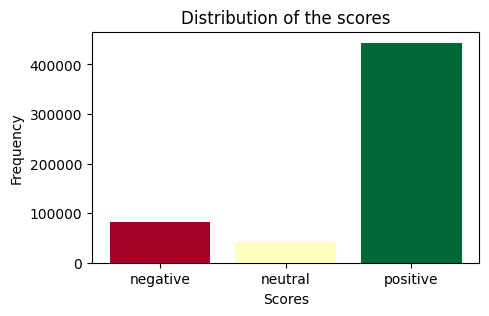

In [12]:
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(senti)))

plt.figure(figsize=(5,3))
plt.bar(senti, senti_counts, color = colors)
plt.title('Distribution of the scores')
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

reviews_train, reviews_test = train_test_split(reviews, test_size=0.25, random_state=18, stratify=reviews["Sentiment"])

In [14]:
min_class_size = reviews_train.Sentiment.value_counts().min()
min_class_size

np.int64(31980)

In [15]:
reviews_train = reviews_train.groupby("Sentiment").apply(lambda x:x.sample(min_class_size, random_state=42)).reset_index(drop = True)

C:\Users\user\AppData\Local\Temp\ipykernel_18760\1202429696.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reviews_train = reviews_train.groupby("Sentiment").apply(lambda x:x.sample(min_class_size, random_state=42)).reset_index(drop = True)


In [16]:
senti= list(np.unique(reviews_train.Sentiment.values))
senti_counts = reviews_train.Sentiment.value_counts().sort_index()

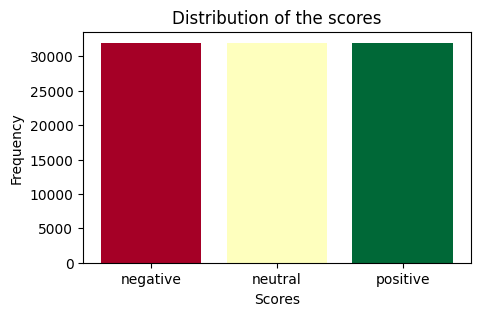

In [17]:
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(senti)))

plt.figure(figsize=(5,3))
plt.bar(senti, senti_counts, color = colors)
plt.title('Distribution of the scores')
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.show()

In [18]:
X_train, _, y_train, _ = train_test_split(
    reviews_train["Text"], reviews_train["Sentiment"], train_size=15000, stratify=reviews_train["Sentiment"], random_state=42
)

X_test, _, y_test, _ = train_test_split(
    reviews_test["Text"], reviews_test["Sentiment"], train_size=5000, stratify=reviews_test["Sentiment"], random_state=42
)

# Rule-based approach

We use ***SentiWordNet***,  a dictionary that assigns sentiment ***polarity scores*** to words. Our rule-based pipeline, implemented with the NLTK library, consists of the following steps:

- **Tokenization**: Breaking down the text into individual words
- **Lemmatization**: Reducing words to their base form (e.g., "running" → "run")
- **Stopword removal**: Filtering out common words without sentiment value (e.g., "the", "is", "a")
- **POS tagging**: Identifying the grammatical role of each word to retrieve the correct synset
- **Score aggregation**: Summing positive and negative scores from SentiWordNet
- **Classification**: Determining sentiment based on threshold values

In [20]:
from tqdm.auto import tqdm
tqdm.pandas() # to be able to use the "progress_apply"

from src.models.SentiWordNet import text_processing, sentiwordnet_scores, swn_predict_sentiment
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [21]:
print(f"The text :\n{reviews.iloc[84].Text}")
print(f"The label :\n{reviews.iloc[84].Sentiment}")

The text :
Awesome dog food. However, when given to my "Boston", who has severe reactions to some food ingredients; his itching increased to violent jumping out of bed at night, scratching. As soon as I changed to a different formula, the scratching stopped. So glad Natural Balance has other choices. I guess you have to try each, until you find what's best for your pet.
The label :
neutral


In [22]:
pos_tags = text_processing(reviews.iloc[84]["Text"], verbose=True)
positive_sentiment, negative_sentiment = sentiwordnet_scores(pos_tags)
print(f"Positivity score : {positive_sentiment} | Negativity score : {negative_sentiment}")

Tokenization...
Lemmatization...
POS tagging...
Positivity score : 3.125 | Negativity score : 3.375


In [23]:
score_diff = positive_sentiment - negative_sentiment

if score_diff > 0.25:
    print("The sentiment of the text is positive.")
elif score_diff < -0.25:
    print("The sentiment of the text is negative.")
else:
    print("The sentiment of the text is neutral.")

The sentiment of the text is neutral.


Let's predict the sentiments of the test set. We use ***tqdm*** to display a progress bar during the loop.

In [24]:
# sample = reviews.sample(1000, random_state=45)
# sample['Sentiment_prediction'] = sample['Text'].progress_apply(swn_predict_sentiment)

In [25]:
print(f"Test set length : {len(X_test)}")

Test set length : 5000


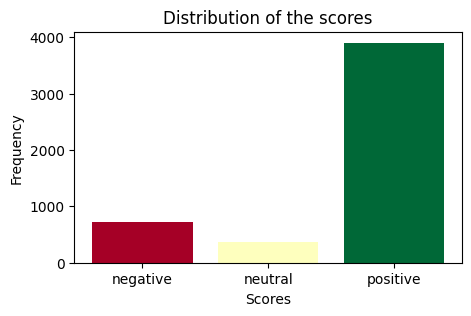

In [26]:
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(senti)))

plt.figure(figsize=(5,3))
plt.bar(senti, y_test.value_counts().sort_index(), color = colors)
plt.title('Distribution of the scores')
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.show()

In [27]:
y_pred_swn = X_test.progress_apply(swn_predict_sentiment)

  0%|          | 0/5000 [00:00<?, ?it/s]

<!-- Since processing all ***568K reviews*** is too heavy, we randomly select a sample of ***1000 reviews*** and predict their sentiment. -->

Evaluating the quality of the predictions

In [28]:
from sklearn.metrics import balanced_accuracy_score

print(f"Balanced accuracy (SentiWordNet) : {balanced_accuracy_score(y_test, y_pred_swn):.4f}")

Balanced accuracy (SentiWordNet) : 0.4700


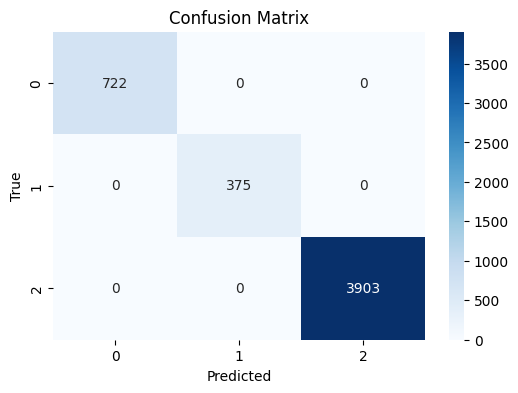

In [28]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_swn)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [29]:
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=senti)
# disp.plot(cmap=plt.cm.Blues)
# plt.title("Confusion Matrix")
# plt.show()

We observe that the ***SentiWordNet-based*** function, which relies on ***rule-based*** lexical scoring, performs ***poorly*** in sentiment classification.

The confusion matrix shows that it predicts reviews as positive or neutral in most cases, even when they aren’t. This highlights a ***common issue*** with rule-based methods : they do not capture contextual information, especially things like negation, which often leads to wrong predictions.

Moreover, the method is computationally expensive. Processing and predicting sentiment for all ***$568K$*** reviews takes a considerable amount of time (~1 hour).

# Machine learning approach

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report

### Word embeddings

In [20]:
tfidf_vectorizer = TfidfVectorizer(stop_words = "english", 
                                 #   max_features=5000,
                                   min_df=5)

In [21]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

In [22]:
X_train_tfidf.shape

(15000, 7598)

In [23]:
model_logistic = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

model_rf = RandomForestClassifier(
    n_estimators=250,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_gb = lgb.LGBMClassifier(
    n_estimators=250,
    num_leaves=50,
    learning_rate=0.1,
    class_weight='balanced',
    force_col_wise=True,    
    random_state=42
)

In [24]:
print("Logistic Regression...")
model_logistic.fit(X_train_tfidf, y_train)

Logistic Regression...


LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

In [25]:
print("Random Forest...")
model_rf.fit(X_train_tfidf, y_train, )

Random Forest...


RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=250,
                       n_jobs=-1, random_state=42)

In [26]:
print("Gradient Boosting (LightGBM)...")
model_gb.fit(X_train_tfidf, y_train)

Gradient Boosting (LightGBM)...
[LightGBM] [Info] Total Bins 124177
[LightGBM] [Info] Number of data points in the train set: 15000, number of used features: 3154
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


LGBMClassifier(class_weight='balanced', force_col_wise=True, n_estimators=250,
               num_leaves=50, random_state=42)

In [27]:
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [28]:
y_pred_logistic = model_logistic.predict(X_test_tfidf)
y_pred_rf = model_rf.predict(X_test_tfidf)
y_pred_gb = model_gb.predict(X_test_tfidf)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [29]:
print(f"Balanced accuracy (Logistic Regression) : {balanced_accuracy_score(y_test, y_pred_logistic):.4f}")
print(f"Balanced accuracy (Random Forest) : {balanced_accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Balanced accuracy (Gradient Boosting) : {balanced_accuracy_score(y_test, y_pred_gb):.4f}")

Balanced accuracy (Logistic Regression) : 0.6816
Balanced accuracy (Random Forest) : 0.6642
Balanced accuracy (Gradient Boosting) : 0.6874


In [30]:
print("Classification Report (Gradient Boosting):\n")
print(classification_report(y_test, y_pred_gb))

Classification Report (Gradient Boosting):

              precision    recall  f1-score   support

    negative       0.56      0.70      0.62       722
     neutral       0.23      0.60      0.33       375
    positive       0.96      0.77      0.85      3903

    accuracy                           0.74      5000
   macro avg       0.58      0.69      0.60      5000
weighted avg       0.85      0.74      0.78      5000



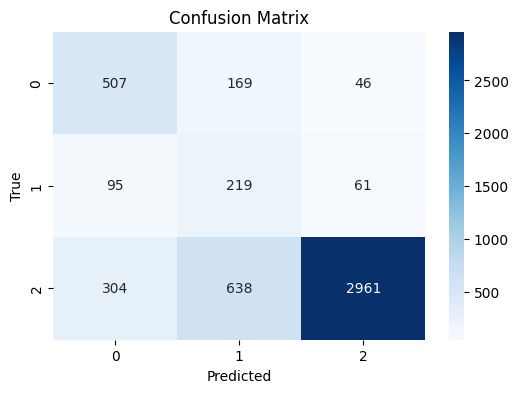

In [31]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_logistic)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Compared to the rule-based method, the ***Machine Learning*** approach proves to be significantly more efficient, boosting balanced accuracy from $47~\%$ to $65~\%$. Results could be further enhanced by adopting word embeddings other than the current ***TF-IDF***, which relies solely on word frequency across documents. This method overlooks critical aspects such as  : 
- Semantics
- Context
- Out-of-Vocabulary terms

Deep learning-based approaches, like ELMo (built on BiLSTM), offer a solution by effectively addressing these limitations.

### ELMo embeddings

In [33]:
import warnings
warnings.filterwarnings(action = "ignore")

import tensorflow_hub as hub
import tensorflow as tf

In [34]:
elmo = hub.load("https://tfhub.dev/google/elmo/3")

In [35]:
def elmo_vectors_batched(x, batch_size=32):

    if hasattr(x, 'tolist'):
        x = x.tolist()
    
    elmo_embeds = []
    
    for i in range(0, len(x), batch_size):
        batch = x[i : i + batch_size]
        
        if i % (batch_size * 10) == 0:
            print(f"Traitement : {i}/{len(x)}")
            
        embeddings = elmo.signatures["default"](tf.constant(batch))["elmo"]        
        mean_embeddings = tf.reduce_mean(embeddings, 1)
        elmo_embeds.append(mean_embeddings.numpy())

    return np.concatenate(elmo_embeds, axis=0)

In [36]:
X_train_elmo = elmo_vectors_batched(X_train, batch_size=32)

Traitement : 0/15000


: 

In [ ]:
X_test_elmo = elmo_vectors_batched(X_test, batch_size=32)

# Transformer-based approach

In this part, we'll discover another types of embedding models, but this time based on the architecture of Transformers which lays on the ***Attention mechanism***.

### BERT pipeline

In [19]:
from transformers import pipeline
from tqdm.auto import tqdm

In [21]:
import warnings
warnings.filterwarnings("ignore")

In [19]:
MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"

In [140]:
model_distilbert = pipeline("sentiment-analysis", model = MODEL, device=-1, framework = "pt", truncation = True, max_length = 512)

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [143]:
all_sentiments = []
batch_size = 64
X_test_list = X_test.tolist()

for i in tqdm(range(0, len(X_test_list), batch_size)):
    batch = X_test_list[i:i+batch_size]
    predictions = model_distilbert(batch)
    sentiments = [pred['label'] for pred in predictions]
    all_sentiments.extend(sentiments)

  0%|          | 0/79 [00:00<?, ?it/s]

In [146]:
y_pred_bert = np.array(all_sentiments)

In [147]:
print(f"Balanced accuracy (BERT) : {balanced_accuracy_score(y_test, y_pred_bert):.4f}")

Balanced accuracy (BERT) : 0.6236


In [148]:
print("Classification Report (BERT):\n")
print(classification_report(y_test, y_pred_bert))

Classification Report (BERT):

              precision    recall  f1-score   support

    negative       0.62      0.76      0.68       722
     neutral       0.20      0.22      0.21       375
    positive       0.94      0.89      0.91      3903

    accuracy                           0.82      5000
   macro avg       0.59      0.62      0.60      5000
weighted avg       0.84      0.82      0.83      5000



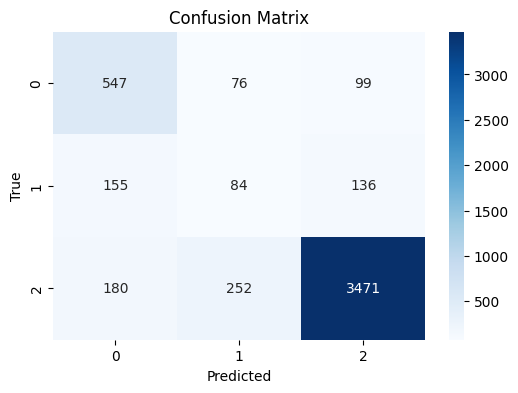

In [149]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_bert)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### BERT Embeddings

In [22]:
import torch
from transformers import AutoTokenizer
from transformers import AutoModel

from tqdm.auto import tqdm

import warnings
warnings.filterwarnings(action="ignore")

In [25]:
# from sentence_transformers import SentenceTransformer

# model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# def get_embedding(X_train, BATCH_SIZE=16):
#     embeddings = model.encode(
#         X_train.tolist(), 
#         batch_size=BATCH_SIZE,  
#         show_progress_bar=True,
#         convert_to_numpy=True
#     )
#     return embeddings

In [23]:
MODEL = "distilbert-base-uncased" #"cardiffnlp/twitter-roberta-base-sentiment-latest" # #"sentence-transformers/all-MiniLM-L6-v2" #"distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(MODEL, model_max_length=128, framework ="pt")
model = AutoModel.from_pretrained(MODEL)

  0%|          | 0/15000 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (166 > 128). Running this sequence through the model will result in indexing errors


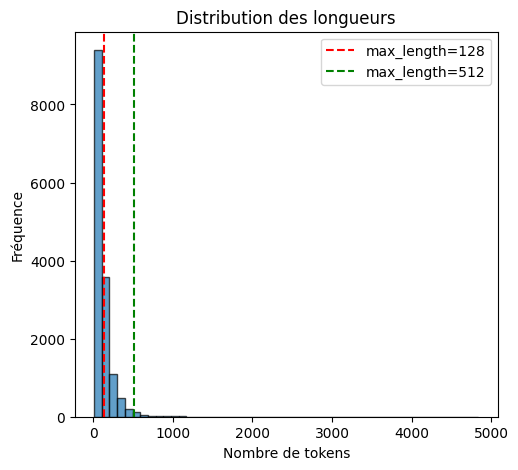

In [24]:
lengths = []
for text in tqdm(X_train.tolist()):
    tokens = tokenizer(str(text), truncation=False)
    lengths.append(len(tokens['input_ids']))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(lengths, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(128, color='r', linestyle='--', label='max_length=128')
plt.axvline(512, color='g', linestyle='--', label='max_length=512')
plt.xlabel('Nombre de tokens')
plt.ylabel('Fréquence')
plt.title('Distribution des longueurs')
plt.legend()

In [ ]:
def mean_pooling(token_embeddings, attention_mask):
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
    sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
    return sum_embeddings / sum_mask

In [ ]:
def get_embeddings(X_train, batch_size = 32):
    embeddings = []
    texts = X_train.tolist()
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i+batch_size]
            encoded = tokenizer(batch, padding = True, truncation = True, max_length = 128, return_tensors = "pt")
            outputs = model(**encoded)            
            batch_emb = mean_pooling(outputs.last_hidden_state, encoded['attention_mask']).numpy()
            embeddings.append(batch_emb)
    return np.vstack(embeddings)

In [ ]:
X_train_transformers = get_embeddings(X_train)

  0%|          | 0/625 [00:00<?, ?it/s]

In [ ]:
X_test_transformers = get_embeddings(X_test)

  0%|          | 0/157 [00:00<?, ?it/s]

In [ ]:
model_logistic_2 = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

model_rf_2 = RandomForestClassifier(
    n_estimators=250,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_gb_2 = lgb.LGBMClassifier(
    n_estimators=250,
    num_leaves=50,
    learning_rate=0.1,
    class_weight='balanced',
    force_col_wise=True,    
    random_state=42
)

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [ ]:
print("Logistic Regression...")
model_logistic_2.fit(X_train_transformers, y_train)

Logistic Regression...


LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

In [ ]:
print("Random Forest...")
model_rf_2.fit(X_train_transformers, y_train, )

Random Forest...


RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=250,
                       n_jobs=-1, random_state=42)

In [ ]:
print("Gradient Boosting (LightGBM)...")
model_gb_2.fit(X_train_transformers, y_train)

Gradient Boosting (LightGBM)...
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 768
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


LGBMClassifier(class_weight='balanced', force_col_wise=True, n_estimators=250,
               num_leaves=50, random_state=42)

In [ ]:
y_pred_logistic_2 = model_logistic_2.predict(X_test_transformers)
y_pred_rf_2 = model_rf_2.predict(X_test_transformers)
y_pred_gb_2 = model_gb_2.predict(X_test_transformers)

In [ ]:
print(f"Balanced accuracy (Logistic Regression) : {balanced_accuracy_score(y_test, y_pred_logistic_2):.4f}")
print(f"Balanced accuracy (Random Forest) : {balanced_accuracy_score(y_test, y_pred_rf_2):.4f}")
print(f"Balanced accuracy (Gradient Boosting) : {balanced_accuracy_score(y_test, y_pred_gb_2):.4f}")

Balanced accuracy (Logistic Regression) : 0.6722
Balanced accuracy (Random Forest) : 0.4183
Balanced accuracy (Gradient Boosting) : 0.5915


In [ ]:
print("Classification Report (Logistic Regression):\n")
print(classification_report(y_test, y_pred_logistic_2))

Classification Report (Logistic Regression):

              precision    recall  f1-score   support

    negative       0.55      0.68      0.60       722
     neutral       0.22      0.56      0.32       375
    positive       0.96      0.78      0.86      3903

    accuracy                           0.75      5000
   macro avg       0.58      0.67      0.59      5000
weighted avg       0.85      0.75      0.78      5000



In [49]:
X_train_transformers.shape

(20000, 768)

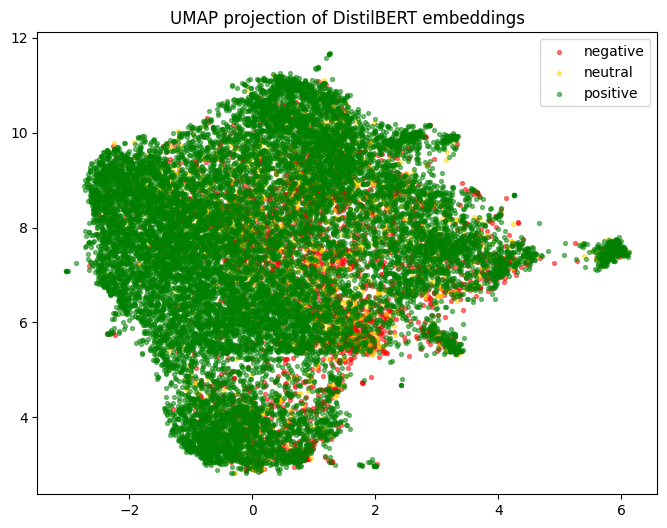

In [57]:
import umap.umap_ as umap


labels = y_train.values

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
umap_res = umap_model.fit_transform(X_train_transformers)

plt.figure(figsize=(8, 6))

unique_labels = np.unique(labels)
colors = ["red", "gold", "green"]

for lab, col in zip(unique_labels, colors):
    idx = labels == lab
    plt.scatter(
        umap_res[idx, 0],
        umap_res[idx, 1],
        s=8,
        alpha=0.5,
        c=col,
        label=lab
    )

plt.title("UMAP projection of DistilBERT embeddings")
plt.legend()
plt.show()



# Saving models

In [ ]:
import joblib

joblib.dump(model_gb, "../saved_models/model_lightgbm.pkl")

['saved_models/model_lightgbm.pkl']

In [ ]:
joblib.dump(tfidf_vectorizer, "../saved_models/tfidf_vectorizer.pkl")

['saved_models/tfidf_vectorizer.pkl']